<a href="https://colab.research.google.com/github/benitodev/prediccion-alquileres-cordoba/blob/main/prediccion_precios_alquiler_cordoba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Córdoba predicción precios alquiler

Modelo de predicción de precios de alquiler en Córdoba Capital (Argentina) utilizando un dataset propio construido mediante web scraping, geocodificación y feature engineering geoespacial.

## Objetivos
- Analizar el mercado de alquileres en Córdoba Capital
- Construir variables útiles a partir de ubicación y distancia
- Entrenar un modelo capaz de estimar el precio de alquiler
- Interpretar resultados y limitaciones del enfoque

# Carga del dataset (csv), compartido de Google Sheet

Para este estudio utilicé un dataset de elaboración propia, construido mediante web scraping de ofertas reales de alquiler en Córdoba Capital (Argentina). Luego, normalicé variables clave (m², ubicación y precio) y enriquecí los registros con geocodificación mediante la API de Nominatim (OpenStreetMap), obteniendo coordenadas (latitud/longitud) para cada publicación.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.float_format', '{:.3f}'.format)

url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRmAIkHLf2tmccPQMVQAytJTOEN3JYQhYqfn9d4V4v3sfpmy6iGTNAvHftYMIS4XyHz_Ut8y6MSHync/pub?gid=480351577&single=true&output=csv"
try:
    df = pd.read_csv(url)


    print("\nPrimeras 5 filas del DataFrame (df_drive):")
    print(df.head())

except FileNotFoundError:
    print(f"\nERROR: No se encontró el archivo en la ruta: {url}. Verifica la ruta y el nombre del archivo.")
except Exception as e:
    print(f"\nOcurrió un error al leer el archivo: {e}")



Primeras 5 filas del DataFrame (df_drive):
   ID                                              title    price  room  \
0   1  Departamento 2 Dormitorios C/cochera Y Balcón....   600000     4   
1   2  Nueva Cba - Alquiler Depto 3 Dorms - 3 Baños -...   950000     7   
2   3  Dueño Alquila - Dpto Amoblado Completo A Estre...  1038750     4   
3   4  Nueva Cordoba 2 Dormitorios 2 Baños Totalmente...  1100000     3   
4   5  Departamento En Alquiler De 3 Dormitorios En N...   800000     4   

   bathroom  square_meter                                           location  \
0         2            64  Martín Pinzon Al 1300, San Martín, San Alberto...   
1         2            80  Fructuoso Rivera 387, Córdoba, Nueva Córdoba, ...   
2         2            97  Prudencio Bustos 125, Córdoba, Alto Alberdi, C...   
3         2            70                     Crisol, Nueva Córdoba, Córdoba   
4         2            80  Marcelo T De Alvear  Al 334 4 C, Nueva Córdoba...   

    neighborhood      ne

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1044 non-null   int64  
 1   title                   1044 non-null   object 
 2   price                   1044 non-null   int64  
 3   room                    1044 non-null   int64  
 4   bathroom                1044 non-null   int64  
 5   square_meter            1044 non-null   int64  
 6   location                1044 non-null   object 
 7   neighborhood            1044 non-null   object 
 8   neighborhood_API        893 non-null    object 
 9   neighborhood_latitude   896 non-null    float64
 10  neighborhood_longitude  896 non-null    float64
dtypes: float64(2), int64(5), object(4)
memory usage: 89.8+ KB


,ID,price,room,bathroom,square_meter,neighborhood_latitude,neighborhood_longitude
count,1044.000,1044.000,1044.000,1044.000,1044.000,896.000,896.000
mean,571.038,633080.699,2.697,1.194,57.090,-31.413,-64.191
std,328.864,331832.044,1.181,0.452,23.717,0.022,0.029
min,1.000,200000.000,1.000,1.000,19.000,-31.486,-64.307
25%,286.750,450000.000,2.000,1.000,42.000,-31.425,-64.197
50%,571.500,550000.000,2.000,1.000,50.000,-31.418,-64.187
75%,856.250,700000.000,3.000,1.000,65.000,-31.404,-64.180
max,1140.000,3462500.000,7.000,4.000,180.000,-31.313,-64.103


# Analisis exploratorio

In [3]:
neighborhoods = df["neighborhood_API"]
print("\nValores unicos:")
print(neighborhoods.unique())
print("\nCantidad de valores unicos")
print(neighborhoods.nunique())
print("\nSuma de todos los datos nulos")
print(neighborhoods.isnull().sum())
#print(neighborhoods.value_counts())


Valores unicos:
['San Martín' 'Nueva Córdoba' 'Alto Alberdi' 'Marcelo T. de Alvear'
 'General Paz' 'Pueyrredón' 'Las Palmas' 'Alberdi' 'Observatorio' 'Centro'
 nan 'Villa Quisquisacate' 'Villa 9 de Julio' 'Poeta Lugones' 'Escobar'
 'Villa Belgrano' 'Alta Córdoba' 'Balcarce' 'Cofico' 'Güemes'
 'Bajo Palermo' 'Barrio Juan B. Justo' 'Cupani' 'San Vicente'
 'Residencial Los Robles' 'Jardines del Valle' 'Saldán Centro'
 'Achaval Peña' 'Las Rosas' 'General Bustos' 'Sarmiento' 'Oña'
 'Chateau Carreras' 'Providencia' 'San Jorge' 'Villa San Carlos'
 'Alto Palermo' 'Empalme' 'Aeronáutico' 'Barrio La Carolina'
 'Tejas de la Candelaria' 'Cerro de las Rosas' 'Colón' 'Villa San Isidro'
 'Los Olmos' 'Paso de Los Andes' 'San Salvador' 'Inaudi'
 'Santa Isabel 2ª Sección' 'Los Plátanos' 'Independencia' 'Patria'
 'Nicolás Avellaneda' 'Deán Funes' 'Ameghino Norte' 'Lomas del Chateau'
 'Villa Esquiú' 'Yofre Sud' 'Alto Verde' 'Argüello' 'Natania 19'
 'Colina Los Pinos' 'Mariano Fragueiro' 'Crisol Norte' 'V

## Analisis univariado

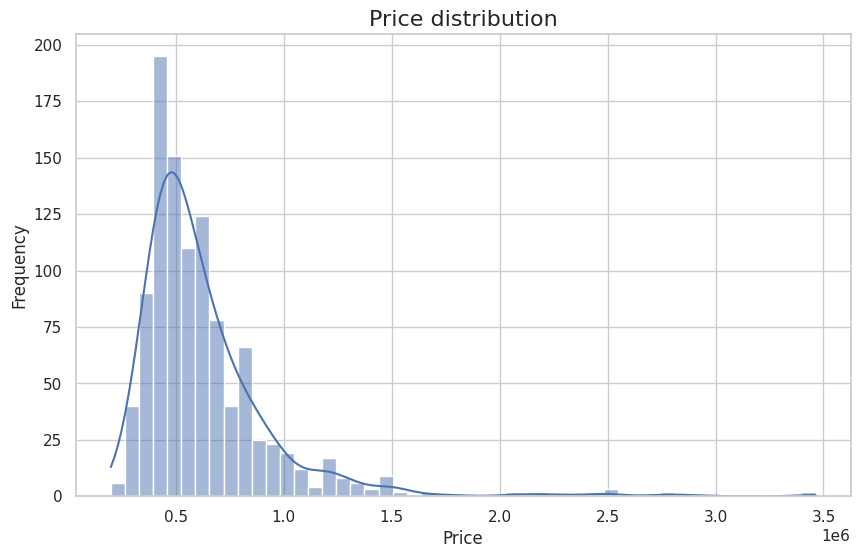

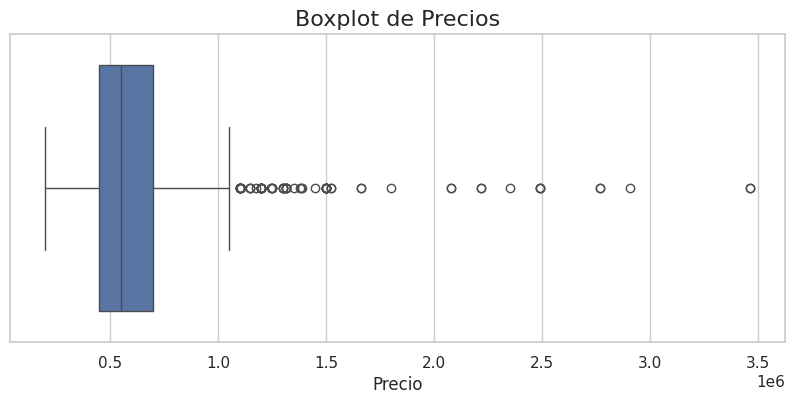

In [4]:
sns.set(style="whitegrid")

# Histograma del Precio
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Price distribution', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Boxplot de price (verificar si hay outliers)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])
plt.title('Boxplot de Precios', fontsize=16)
plt.xlabel('Precio')
plt.show()

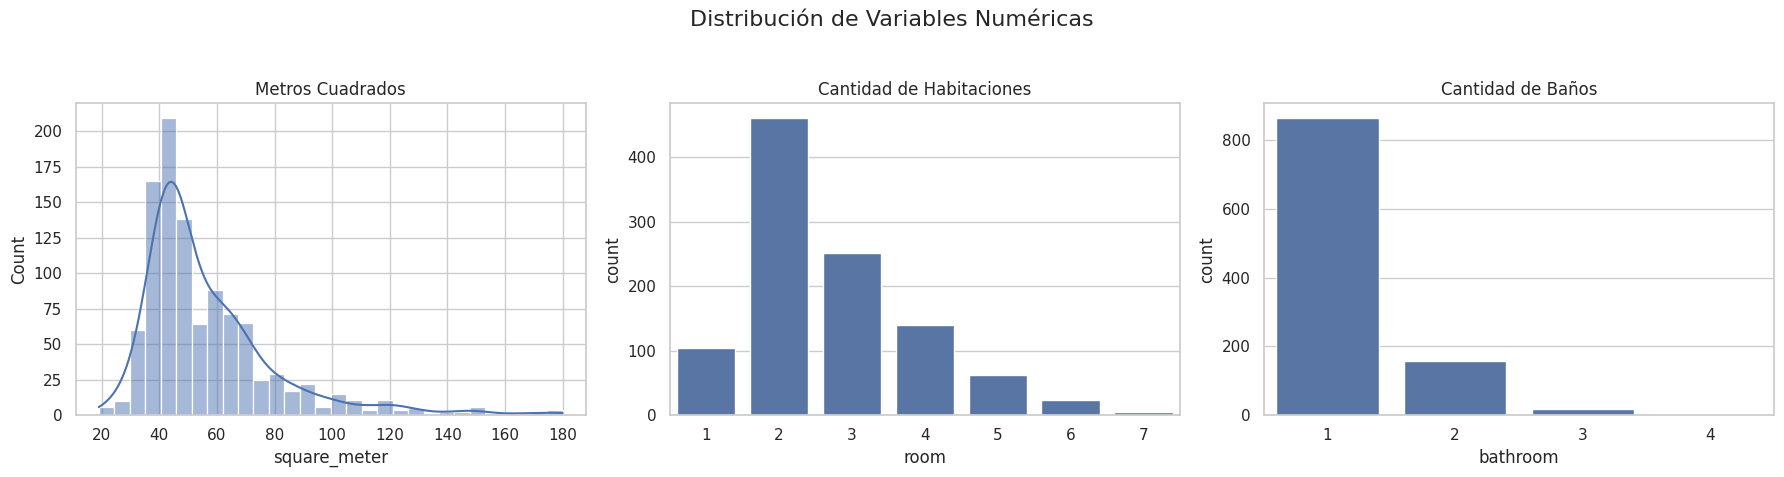

In [5]:
# 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Square_meter
sns.histplot(df['square_meter'], kde=True, ax=axes[0], bins=30)
axes[0].set_title('Metros Cuadrados')

# Room
# Usamos countplot porque son valores discretos (1, 2, 3...)
sns.countplot(x=df['room'], ax=axes[1])
axes[1].set_title('Cantidad de Habitaciones')

# Bathroom
sns.countplot(x=df['bathroom'], ax=axes[2])
axes[2].set_title('Cantidad de Baños')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el título principal
plt.show()

## Análisis Multivariado

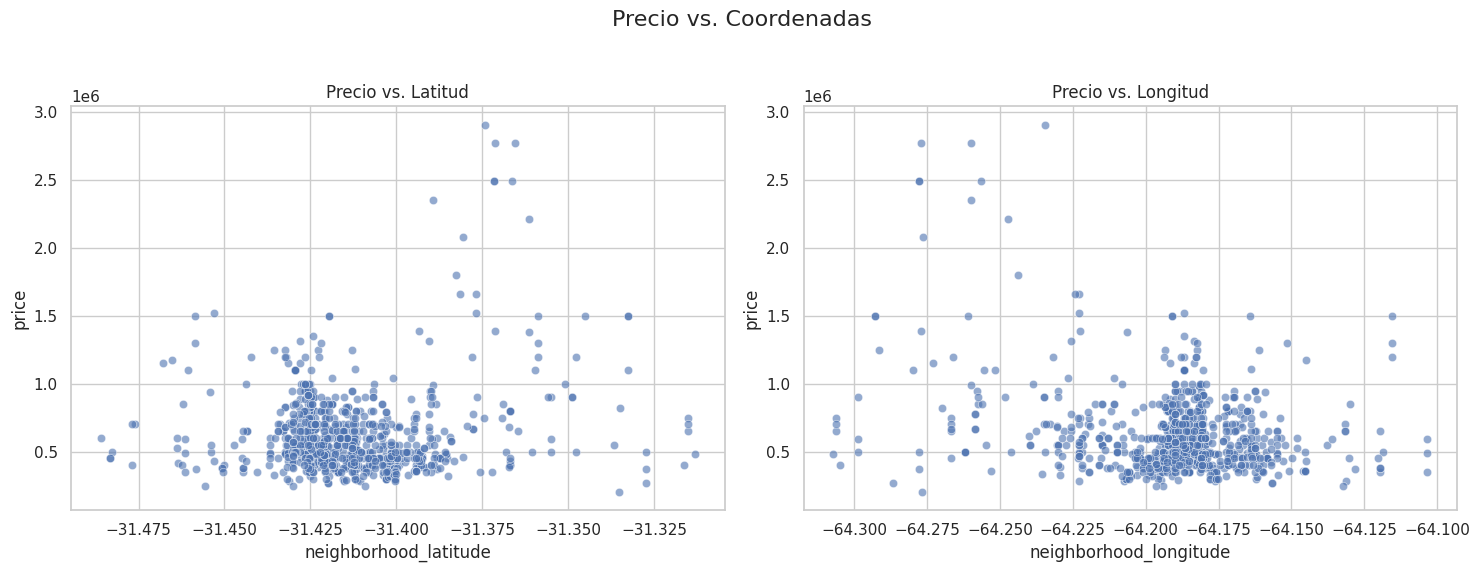

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Precio vs. Coordenadas', fontsize=16)

# Precio vs. Latitud
sns.scatterplot(data=df, x='neighborhood_latitude', y='price', ax=axes[0], alpha=0.6)
axes[0].set_title('Precio vs. Latitud')

# Precio vs. Longitud
sns.scatterplot(data=df, x='neighborhood_longitude', y='price', ax=axes[1], alpha=0.6)
axes[1].set_title('Precio vs. Longitud')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

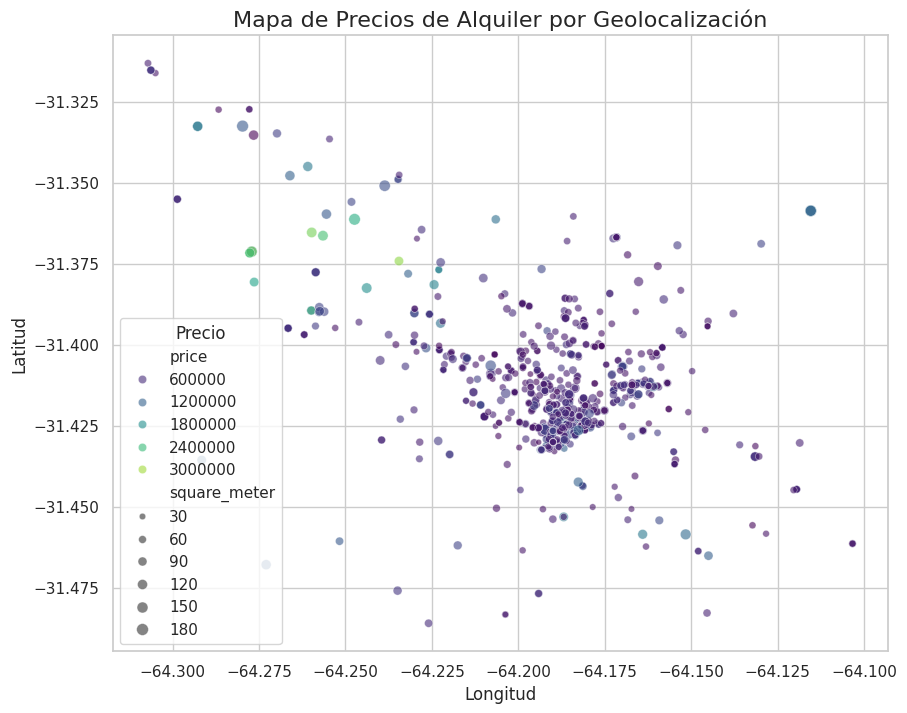

In [7]:
plt.figure(figsize=(10, 8))
# Usamos las coordenadas del neighborhood_API, que tienen valores nulos que Seaborn gestiona.
sns.scatterplot(
    data=df,
    x='neighborhood_longitude',
    y='neighborhood_latitude',
    hue='price',
    palette='viridis',
    size='square_meter', # tamaño del punto refleja los m2
    alpha=0.6
)
plt.title('Mapa de Precios de Alquiler por Geolocalización', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Precio', loc='lower left')
plt.show()

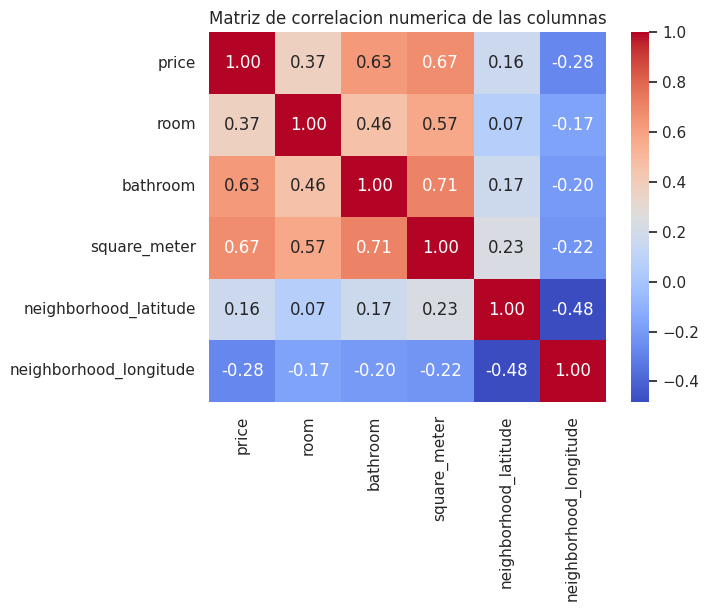

In [8]:

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("ID")


correlation_matrix = pd.DataFrame(df[numerical_cols]).corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlacion numerica de las columnas")
plt.show()

# Preprocesamiento y Limpieza de Datos

## Manejo Datos Nulos
No se utilizarán técnicas de imputación debido a que se eliminarán todas las filas cuyas columnas de latitud y longitud falte. Son variables muy importantes para el modelo y creación de variables.

In [9]:
coordinate_cols = ["neighborhood_API", "neighborhood_latitude", "neighborhood_longitude"]
missing_coords_mask = df[coordinate_cols].isnull().any(axis=1)
print(f"\nNumero total de datos nulos: {missing_coords_mask.sum()}")


titles_missing_coords = df.loc[missing_coords_mask, "title"]
print(f"\nPrimeros 10 titulos que les faltan coordenadas:\n{titles_missing_coords.head(10)}", "\n")

# Solución temporal para mantener la calidad de datos para el modelo predictorio
df_clean = df.dropna(subset=["neighborhood_latitude", "neighborhood_longitude"]).copy()

print(f"Filas anteriores: {len(df)}")
print(f"Filas actuales: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}", "\n")


print(f"Validación (datos nulos en las categorias geolocales): \n{df_clean[['neighborhood_latitude', 'neighborhood_longitude']].isnull().sum()}")

df_clean["neighborhood_API"] = df_clean["neighborhood_API"].fillna("Desconocido")


Numero total de datos nulos: 151

Primeros 10 titulos que les faltan coordenadas:
15    Departamento 2 Dormitorios Con Cochera En Alqu...
20          Departamento Alquiler 2dorm. Bº General Paz
28    Alquiler Duplex Amoblado Dos Dorm San Ignacio ...
38    Alquiler 1 Dormitorio, Fragueiro 100, (edifici...
43       Alquiler Departamento Penthouse Barrio Alberdi
48    Departamento En Alquiler En Cañada, 1 Dormitor...
55    2 Dormitorios - 2 Balcones - Piso 7 -alquiler ...
57    Alquiler Costas De Manantiales- Departamento D...
59    Alquiler Departamento Un Dormitorio Con Patio ...
72               Alquiler Nueva Córdoba,  A Estrenar!!!
Name: title, dtype: object 

Filas anteriores: 1044
Filas actuales: 896
Filas eliminadas: 148 

Validación (datos nulos en las categorias geolocales): 
neighborhood_latitude     0
neighborhood_longitude    0
dtype: int64


## Duplicados

In [10]:
# Verificamos tipos actuales
print("Tipos de datos originales:")
print(df[['price', 'square_meter']].dtypes)

# Convertimos a numérico (por las dudas si llegan como texto)
# 'coerce' transforma errores (textos no numéricos) en NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['square_meter'] = pd.to_numeric(df['square_meter'], errors='coerce')

# Gestión de Duplicados
filas_antes = len(df)
df = df.drop_duplicates()
filas_despues = len(df)
print(f"\nFilas duplicadas eliminadas: {filas_antes - filas_despues}")

Tipos de datos originales:
price           int64
square_meter    int64
dtype: object

Filas duplicadas eliminadas: 0


## Manejo de datos atipicos (outliers)
No se utilizarán tecnicas de Rango Intercuartílico, Z-Scorem, Capping, etc. debido a que se quieren estos datos atipicos para que el modelo pueda interpretar mejor las zonas con precios muy altos gracias a los distintos Cluster aportados por K-means para que el Gradient Boosting pueda asignarles una *etiqueta*.

# Feature Engineering

## Cluster Features (K-means)
Técnica utilizada para Captura de Patrones No Lineales y Vecindad

**Solución K-Means**: Al generar la variable *cluster_zone*, le entregamos al modelo una etiqueta directa que agrupa propiedades vecinas. Esto permite al modelo aprender rápidamente que, por ejemplo, el Cluster 8 corresponde a una zona de "Alto Valor", reduciendo drásticamente la complejidad computacional necesaria para detectar estos patrones.

In [11]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=12, random_state=42, n_init=10)
X_coords = df_clean[["neighborhood_latitude","neighborhood_longitude"]]
df_clean["cluster_zone"] = kmeans.fit_predict(X_coords)

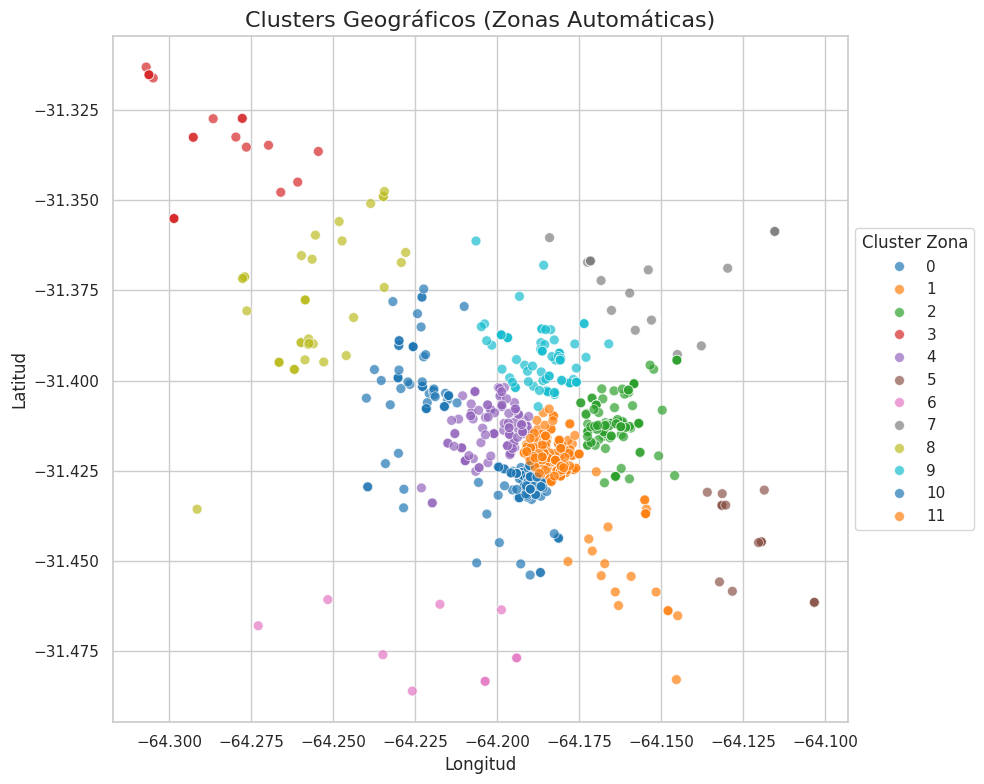

In [12]:
# Visualización: Mapa de Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_clean,
    x='neighborhood_longitude',
    y='neighborhood_latitude',
    hue='cluster_zone',
    palette='tab10',
    alpha=0.7,
    s=50
)
plt.title('Clusters Geográficos (Zonas Automáticas)', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Cluster Zona', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()



/tmp/ipykernel_1418/2204690016.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_zone', y='price', data=df_clean, order=order, palette='tab10')


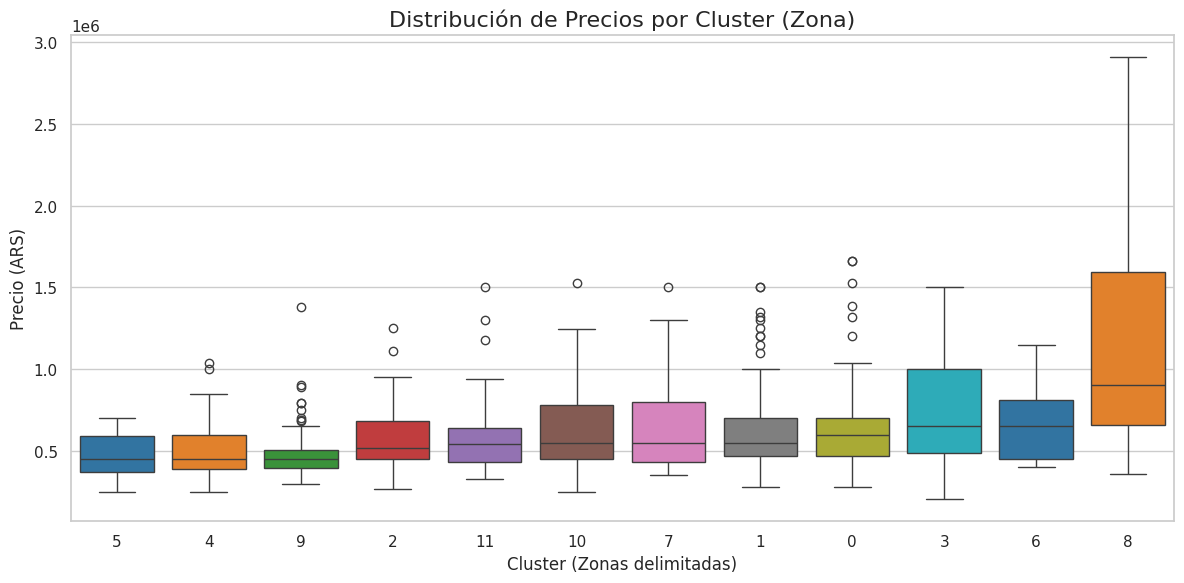

In [13]:
# Análisis de Precio por Cluster (Para ver si capturó las zonas caras)
order = df_clean.groupby("cluster_zone")["price"].median().sort_values().index
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster_zone', y='price', data=df_clean, order=order, palette='tab10')
plt.title('Distribución de Precios por Cluster (Zona)', fontsize=16)
plt.xlabel('Cluster (Zonas delimitadas)')
plt.ylabel('Precio (ARS)')
plt.tight_layout()

In [14]:
table_statistics = df_clean.groupby("cluster_zone")["price"].agg(Quantity="count", Min_Price="min", Max_Price="max", Avg_Price="mean", Median_Price="median",  Deviation="std").sort_values(by="Median_Price", ascending=False)
print(table_statistics)

              Quantity  Min_Price  Max_Price   Avg_Price  Median_Price  \
cluster_zone                                                             
8                   39     360000    2908500 1189115.385    900000.000   
3                   19     205000    1500000  762631.579    650000.000   
6                   10     400000    1150000  681500.000    650000.000   
0                   65     280000    1662000  659261.538    600000.000   
10                 137     250000    1523500  632664.234    550000.000   
1                  255     280000    1500000  612277.451    550000.000   
7                   21     350000    1500000  670476.190    550000.000   
11                  22     330000    1500000  627602.273    540000.000   
2                  121     270000    1250000  569958.678    520000.000   
5                   17     250000     700000  475294.118    450000.000   
4                  110     250000    1040000  502909.091    450000.000   
9                   80     300000    1

In [15]:
import numpy as np

interest_points = {
    'Centro': (-31.4161, -64.1839),
    'UNC (Ciudad Universitaria)': (-31.435, -64.193),
    'Nuevocentro Shopping': (-31.410, -64.208)
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

# Calculamos las 3 distancias
for name, (lat, lon) in interest_points.items():
    col_name = f'dist_{name.split()[0].lower()}_km'
    df_clean[col_name] = haversine(
        df_clean['neighborhood_latitude'], df_clean['neighborhood_longitude'],
        lat, lon
    )

# Data Splitting

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

features = [
    # Características Físicas
    'square_meter',
    'room',
    'bathroom',

    # Nivel socioeconómico de la zona
    'cluster_zone',

    # Valor por cercanía
    'dist_centro_km',
    'dist_unc_km',
    'dist_nuevocentro_km',

    # Ubicación Exacta (Para patrones direccionales N/S/O/E)
    'neighborhood_latitude',
    'neighborhood_longitude'
]
X = df_clean[features]

y_log = np.log1p(df_clean["price"])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Data to train: {len(X_train)}")
print(f"Data to test: {len(X_test)}")


Data to train: 716
Data to test: 180


# Model Training

Se eligió **Gradient Boosting Regressor** porque su enfoque iterativo de corrección de errores permite capturar las sutilezas y no-linealidades del mercado inmobiliario (como saltos de precio por zona) con mayor precisión que los modelos de promedio como Random Forest, especialmente al utilizar una tasa de aprendizaje baja para garantizar la generalización y evitar el overfitting.

In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score


model = GradientBoostingRegressor(n_estimators=200, max_depth=10, random_state=42, learning_rate=0.01, subsample=0.7)

print("Training model...")
model.fit(X_train, y_train_log)
print("Model trained")

Training model...
Model trained


In [18]:
preds_log = model.predict(X_test)

preds_normal_scale = np.expm1(preds_log)
y_test_normal_scale = np.expm1(y_test_log)

mae = mean_absolute_error(y_test_normal_scale, preds_normal_scale)
r2 = r2_score(y_test_normal_scale, preds_normal_scale)

In [19]:
print("Resultados finales:")
print(f"Error promedio: {mae}")
print(f"Precisión con r2 score: {r2}")


example = pd.DataFrame({
    'Real': y_test_normal_scale,
    'Predicción': preds_normal_scale,
    'Diferencia': preds_normal_scale - y_test_normal_scale
}).head(10)
print("\n--- Primeras 10 prediciones del Test ---")
print(example)

Resultados finales:
Error promedio: 115744.55092602414
Precisión con r2 score: 0.6149285983579937

--- Primeras 10 prediciones del Test ---
          Real  Predicción  Diferencia
845 390000.000  551591.790  161591.790
528 700000.000  573956.482 -126043.518
625 450000.000  481373.521   31373.521
856 450000.000  485271.285   35271.285
44  500000.000  488038.959  -11961.041
335 550000.000  521676.186  -28323.814
350 450000.000  471172.068   21172.068
398 650000.000  566741.154  -83258.846
244 300000.000  369361.437   69361.437
159 880000.000  435144.680 -444855.320


# Validación y justificación

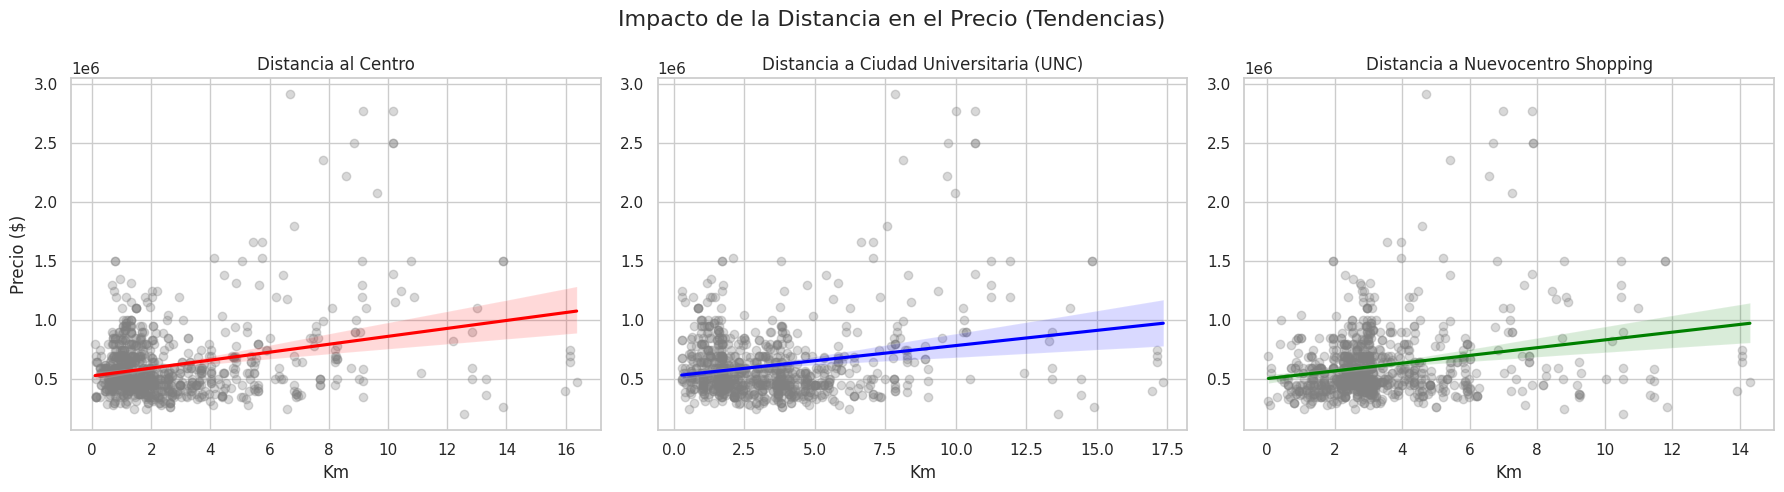

,price,dist_centro_km,dist_unc_km,dist_nuevocentro_km
price,1.000,0.290,0.230,0.232
dist_centro_km,0.290,1.000,0.917,0.807
dist_unc_km,0.230,0.917,1.000,0.758
dist_nuevocentro_km,0.232,0.807,0.758,1.000


In [20]:
# Tendencias de Precio vs. Distancias
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impacto de la Distancia en el Precio (Tendencias)', fontsize=16)

# Distancia al Centro
sns.regplot(data=df_clean, x='dist_centro_km', y='price', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
axes[0].set_title('Distancia al Centro')
axes[0].set_ylabel('Precio ($)')
axes[0].set_xlabel('Km')

# Distancia a UNC
sns.regplot(data=df_clean, x='dist_unc_km', y='price', ax=axes[1],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'blue'})
axes[1].set_title('Distancia a Ciudad Universitaria (UNC)')
axes[1].set_ylabel('')
axes[1].set_xlabel('Km')

# Distancia a Shopping
sns.regplot(data=df_clean, x='dist_nuevocentro_km', y='price', ax=axes[2],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'green'})
axes[2].set_title('Distancia a Nuevocentro Shopping')
axes[2].set_ylabel('')
axes[2].set_xlabel('Km')

plt.tight_layout()
plt.show()

df_clean[['price', 'dist_centro_km', 'dist_unc_km', 'dist_nuevocentro_km']].corr()


## Variables más importantes
Utilizando la Reducción de Impureza (o Varianza) con *feature_importances_*, se puede explicar la importancia de cada una de las variables y justificar la creación de las mismas (feature engineering).

El cálculo matemático (Error Cuadrático Medio - MSE) utilizado por los arbole s exacto de cuánto error (varianza) fue eliminado gracias a la existencia de esa variable en los datos.

/tmp/ipykernel_1418/452313677.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')


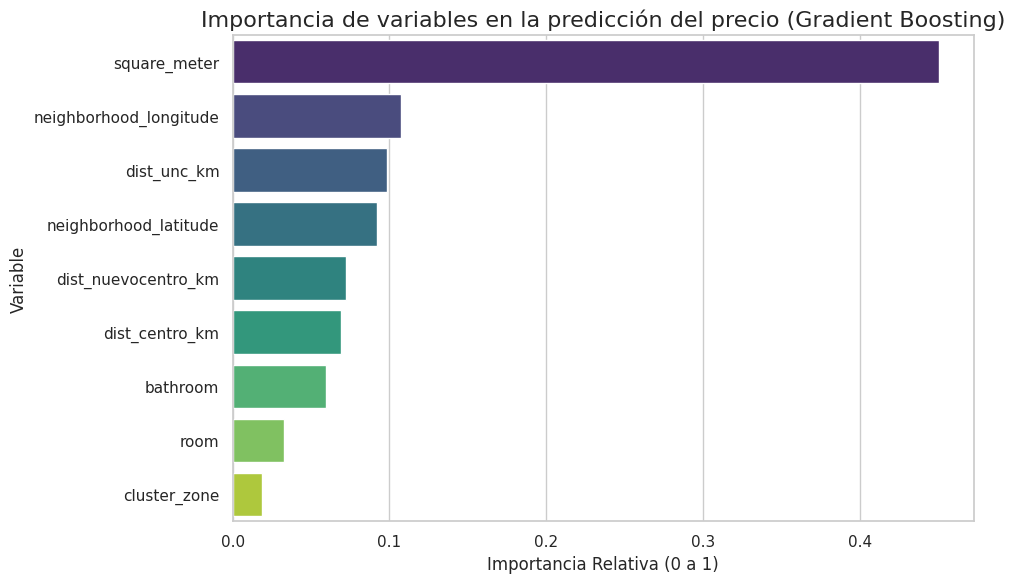

In [23]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Importancia de variables en la predicción del precio (Gradient Boosting)', fontsize=16)
plt.xlabel('Importancia Relativa (0 a 1)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()



## Analisis de residuos
Técnica de diagnóstico fundamental para validar que un modelo de regresión es confiable y no solo "preciso" en promedio.

Se basa en estudiar los errores individuales *(Valor Real - Valor Predicho)* para detectar patrones ocultos que el R2 o el MAE no muestran



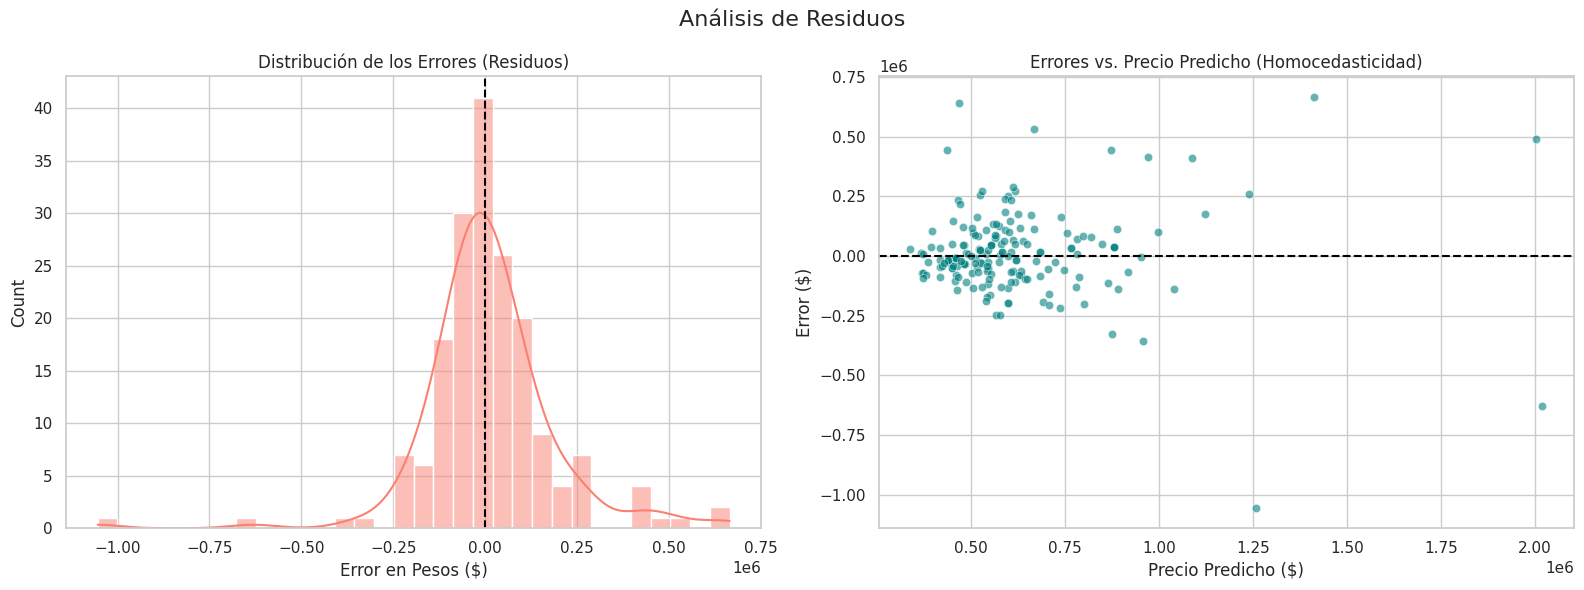

In [22]:
residuals = y_test_normal_scale - preds_normal_scale

# Gráficos de Residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Residuos', fontsize=16)

# Gráfica izquierda: Histograma de Residuos
sns.histplot(residuals, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribución de los Errores (Residuos)')
axes[0].set_xlabel('Error en Pesos ($)')
axes[0].axvline(x=0, color='black', linestyle='--')

# Gráfica derecha: Residuos vs Prediccion
sns.scatterplot(x=preds_normal_scale, y=residuals, ax=axes[1], alpha=0.6, color='teal')
axes[1].set_title('Errores vs. Precio Predicho (Homocedasticidad)')
axes[1].set_xlabel('Precio Predicho ($)')
axes[1].set_ylabel('Error ($)')
axes[1].axhline(y=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

### Explicación de las gráficas
**Histograma de Residuos (Gráfico Izquierdo)**
Muestra la frecuencia y distribución de los errores del modelo.

- Interpretación: La distribución observada, de forma aproximadamente acampanada, sugiere que el modelo no presenta un sesgo marcado de sobreestimación o subestimación en el comportamiento general del mercado. Las pequeñas colas en ambos extremos indican la presencia de algunos casos aislados con errores elevados, probablemente asociados a propiedades atípicas.

**Residuos vs. Predicción (Gráfico Derecho)**
Relaciona el precio que predijo el modelo con el error que cometió en esa predicción específica.

- Interpretación: Para el rango de precios estándar (la mayoría de los datos), la nube es compacta y uniforme, lo que valida que el modelo es robusto y confiable para el mercado general. La dispersión aumenta levemente en los valores más altos, señalando que la incertidumbre es mayor al tasar propiedades de lujo

# Conclusión

###**Limitaciones Identificadas**
El análisis de residuos reveló dónde el modelo pierde precisión: el Segmento de Ultra-Lujo (>2M).

¿Por qué falla aquí?: El modelo ve que un departamento tiene 150m^2$ y está en el Cerro de las Rosas (Cluster 8), por lo que predice un precio alto. Pero no sabe si ese departamento tiene pisos de mármol, grifería de oro, o si está en ruinas. Esa diferencia de "calidad intrínseca" es invisible para el Excel actual.

Falta de Servicios: No sabemos si el edificio tiene pileta, gimnasio, seguridad 24hs o SUM. En el mercado premium, estos servicios pueden duplicar el valor de las expensas y del alquiler, y hoy son una variable oculta (ruido) para el modelo.


###**Impacto de Negocio y Aplicaciones Prácticas**
A pesar de las limitaciones, este modelo tiene un valor comercial inmediato:

Detección de Oportunidades:
Si el modelo predice que un depto debería valer 600k y está listado a $450k, es una alerta automática de "Oportunidad de Inversión" (o de posible estafa/error).

Tasación Masiva (AVM): Permite valuar carteras enteras de propiedades en segundos, algo imposible para un tasador humano.

Validación de Precios: Sirve como "segunda opinión" objetiva para inmobiliarias al momento de captar propiedades, ayudando a convencer a propietarios de ajustar precios fuera de mercado.

###**Cómo mejorar el modelo**: (Cómo llegar al 70-80% de Precisión)
Para romper el techo del 60%, no se necesitan mejores algoritmos, necesito mejores datos.

El plan de acción podría ser:

Minería de Texto (NLP): Procesar la columna title o description (agregar descripción mediante el web scrapping) para buscar palabras clave como "Pileta", "Estrenar", "Seguridad", "Vista". Convertir estas palabras en columnas (0 o 1) reduciría drásticamente el error en el segmento de lujo.

Variable de Antigüedad: Variable física muy importante que falta. Un depto de 1980 vale muy distinto a uno de 2024 en la misma cuadra.

Disposición: Saber si es "Frente" (más caro) o "Interno/Contra-frente" (más barato) afinaría la puntería en edificios del centro.

